In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = '../data/'

tables = ['orders', 'order_items', 'order_payments',
          'order_reviews', 'customers', 'sellers',
          'products', 'geolocation', 'product_category_translation']

dfs = {}
for name in tables:
    dfs[name] = pd.read_csv(f'{DATA_PATH}cleaned_{name}.csv')

date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    dfs['orders'][col] = pd.to_datetime(dfs['orders'][col])

dfs['orders']['order_year_month'] = pd.to_datetime(
    dfs['orders']['order_purchase_timestamp']).dt.to_period('M')

print('All cleaned datasets loaded ✓')

All cleaned datasets loaded ✓


In [2]:
master = (
    dfs['order_items']
    .merge(dfs['orders'],    on='order_id',    how='left')
    .merge(dfs['customers'], on='customer_id', how='left')
    .merge(dfs['products'],  on='product_id',  how='left')
    .merge(dfs['product_category_translation'],
           on='product_category_name', how='left')
    .merge(dfs['order_reviews'][['order_id','review_score']],
           on='order_id', how='left')
    .merge(dfs['order_payments'][['order_id','payment_value']],
           on='order_id', how='left')
)

print(f'Master table shape: {master.shape}')
print(master.head(3))

Master table shape: (118310, 35)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   

   shipping_limit_date  price  freight_value  \
0  2017-09-19 09:45:35  58.90          13.29   
1  2017-05-03 11:05:13 239.90          19.93   
2  2018-01-18 14:48:30 199.00          17.87   

                        customer_id order_status order_purchase_timestamp  \
0  3ce436f183e68e07877b285a838db11a    delivered      2017-09-13 08:59:02   
1  f6dd3ec061db4e3987629fe6b26e5cce    delivered      2017-04-26 10:53:06   
2  6489ae5e4333f3693df5ad4372dab6

In [3]:
seller_stats = (
    dfs['order_items']
    .groupby('seller_id')
    .agg(
        total_orders  = ('order_id',  'nunique'),
        total_items   = ('order_item_id', 'count'),
        total_revenue = ('price', 'sum'),
        avg_price     = ('price', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print('Top 10 Sellers by Revenue:')
display(seller_stats.head(10))

print(f'\nTotal active sellers: {len(seller_stats):,}')
print(f'Median seller revenue: R$ {seller_stats["total_revenue"].median():,.2f}')
print(f'Top seller revenue:    R$ {seller_stats["total_revenue"].max():,.2f}')

Top 10 Sellers by Revenue:


,seller_id,total_orders,total_items,total_revenue,avg_price
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,198.51
1013,53243585a1d6dc2643021fd1853d8905,358,410,222776.05,543.36
881,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,100.89
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,331.13
1535,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,137.77
1560,7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,518.92
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,103.31
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,121.05
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,97.32
1824,955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70,90.17



Total active sellers: 3,095
Median seller revenue: R$ 821.48
Top seller revenue:    R$ 229,472.63


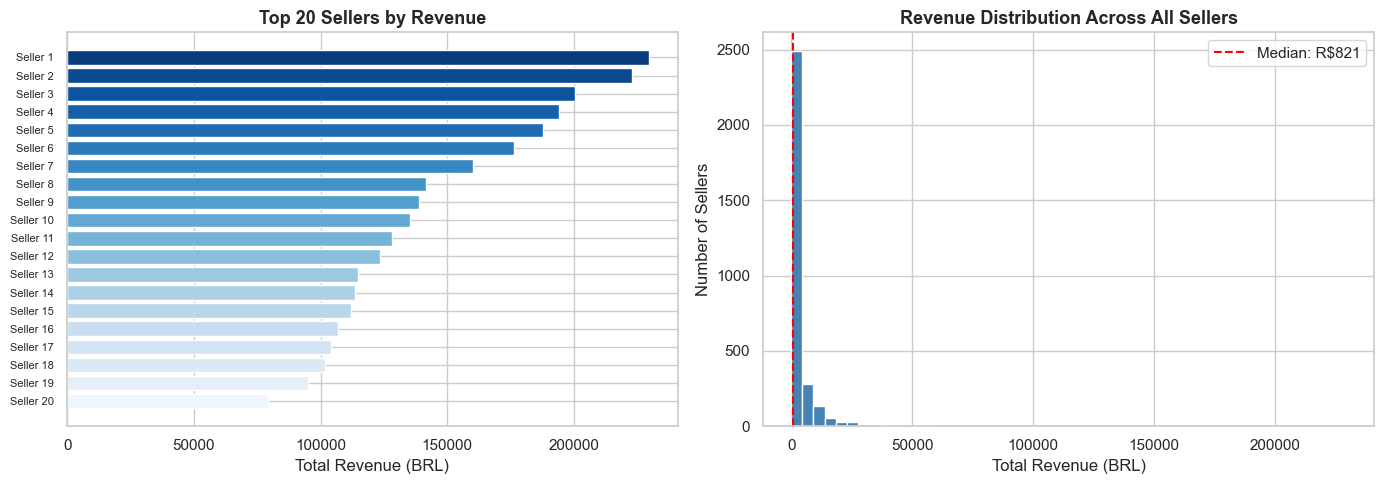

Saved to outputs/seller_performance.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 sellers bar chart
top20 = seller_stats.head(20)
axes[0].barh(range(20), top20['total_revenue'],
             color=sns.color_palette('Blues_r', 20))
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([f'Seller {i+1}' for i in range(20)], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Sellers by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue (BRL)')

# Revenue histogram — all sellers
axes[1].hist(seller_stats['total_revenue'], bins=50,
             color='steelblue', edgecolor='white')
axes[1].set_title('Revenue Distribution Across All Sellers',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].set_ylabel('Number of Sellers')
axes[1].axvline(seller_stats['total_revenue'].median(),
                color='red', linestyle='--',
                label=f'Median: R${seller_stats["total_revenue"].median():,.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/seller_performance.png')

Total unique customers : 96,096
One-time buyers        : 93,099  (96.9%)
Repeat buyers          : 2,997  (3.1%)


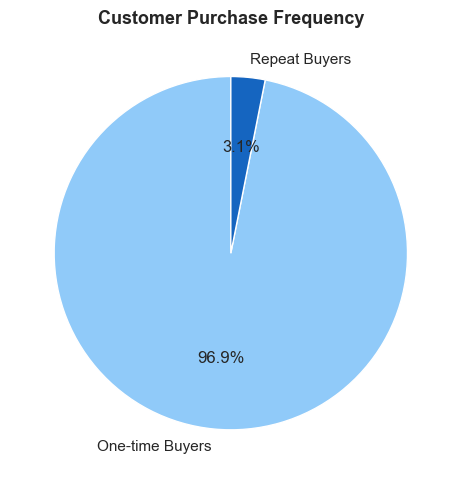

Saved to outputs/customer_repeat_analysis.png


In [5]:
# How many customers ordered more than once?
customer_orders = (
    dfs['orders']
    .merge(dfs['customers'], on='customer_id', how='left')
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
)
customer_orders.columns = ['customer_unique_id', 'order_count']

repeat_customers = customer_orders[customer_orders['order_count'] > 1]
one_time_customers = customer_orders[customer_orders['order_count'] == 1]

print(f'Total unique customers : {len(customer_orders):,}')
print(f'One-time buyers        : {len(one_time_customers):,}  ({len(one_time_customers)/len(customer_orders)*100:.1f}%)')
print(f'Repeat buyers          : {len(repeat_customers):,}  ({len(repeat_customers)/len(customer_orders)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['One-time Buyers', 'Repeat Buyers']
sizes  = [len(one_time_customers), len(repeat_customers)]
colors = ['#90CAF9', '#1565C0']
ax.pie(sizes, labels=labels, autopct='%1.1f%%',
       colors=colors, startangle=90)
ax.set_title('Customer Purchase Frequency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/customer_repeat_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/customer_repeat_analysis.png')

C:\Users\W T\AppData\Local\Temp\ipykernel_19596\2030873436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=price_review, x='review_score', y='price',


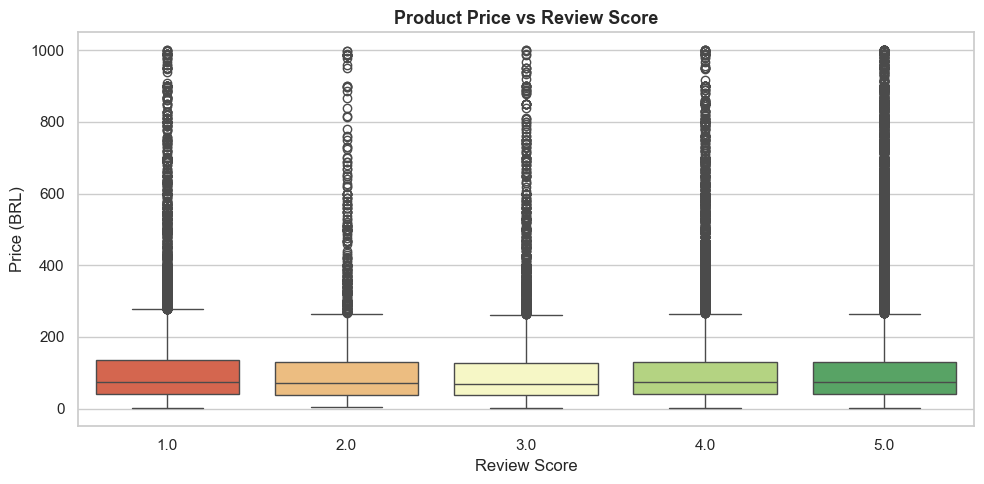

Saved to outputs/price_vs_review.png


In [6]:
price_review = master[['price', 'review_score']].dropna()
price_review = price_review[price_review['price'] < 1000]  # remove extreme outliers

plt.figure(figsize=(10, 5))
sns.boxplot(data=price_review, x='review_score', y='price',
            palette='RdYlGn')
plt.title('Product Price vs Review Score', fontsize=13, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Price (BRL)')
plt.tight_layout()
plt.savefig('../outputs/price_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/price_vs_review.png')

Freight Value Stats:
count   112650.00
mean        19.99
std         15.81
min          0.00
25%         13.08
50%         16.26
75%         21.15
max        409.68
Name: freight_value, dtype: float64

Average freight as % of total payment: 21.3%


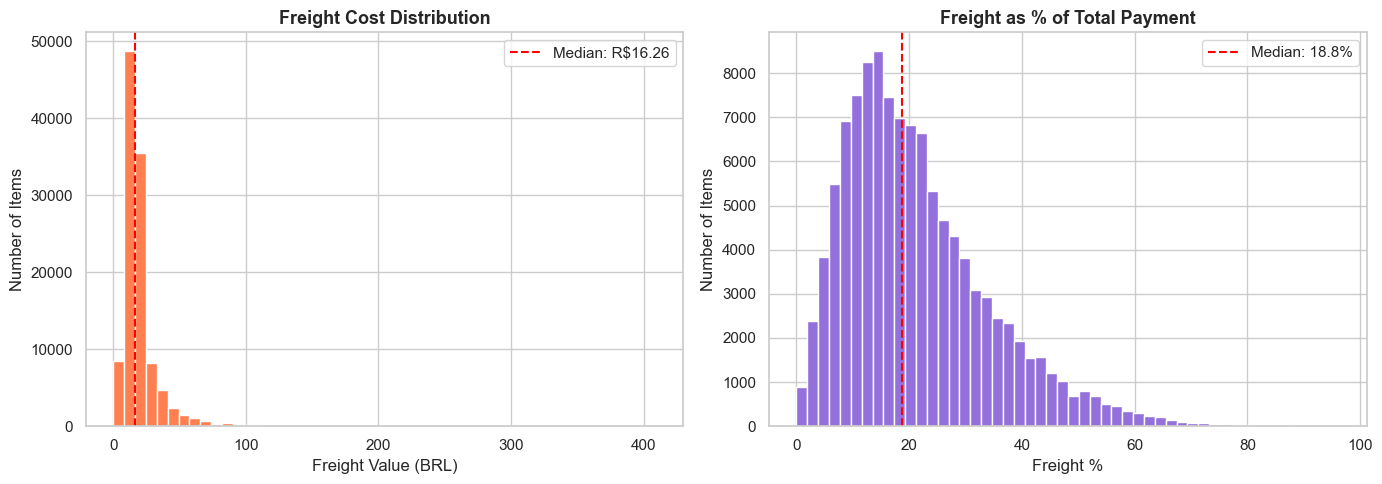

Saved to outputs/freight_analysis.png


In [7]:
freight = dfs['order_items'][['price', 'freight_value']].dropna()
freight['freight_pct'] = freight['freight_value'] / (freight['price'] + freight['freight_value']) * 100

print('Freight Value Stats:')
print(freight['freight_value'].describe())
print(f'\nAverage freight as % of total payment: {freight["freight_pct"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(freight['freight_value'], bins=50,
             color='coral', edgecolor='white')
axes[0].set_title('Freight Cost Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Freight Value (BRL)')
axes[0].set_ylabel('Number of Items')
axes[0].axvline(freight['freight_value'].median(), color='red',
                linestyle='--',
                label=f'Median: R${freight["freight_value"].median():.2f}')
axes[0].legend()

axes[1].hist(freight['freight_pct'], bins=50,
             color='mediumpurple', edgecolor='white')
axes[1].set_title('Freight as % of Total Payment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Freight %')
axes[1].set_ylabel('Number of Items')
axes[1].axvline(freight['freight_pct'].median(), color='red',
                linestyle='--',
                label=f'Median: {freight["freight_pct"].median():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/freight_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/freight_analysis.png')

C:\Users\W T\AppData\Local\Temp\ipykernel_19596\3711677373.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_stats, x='total_orders', y='customer_state',
C:\Users\W T\AppData\Local\Temp\ipykernel_19596\3711677373.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_stats.sort_values('total_revenue', ascending=False),


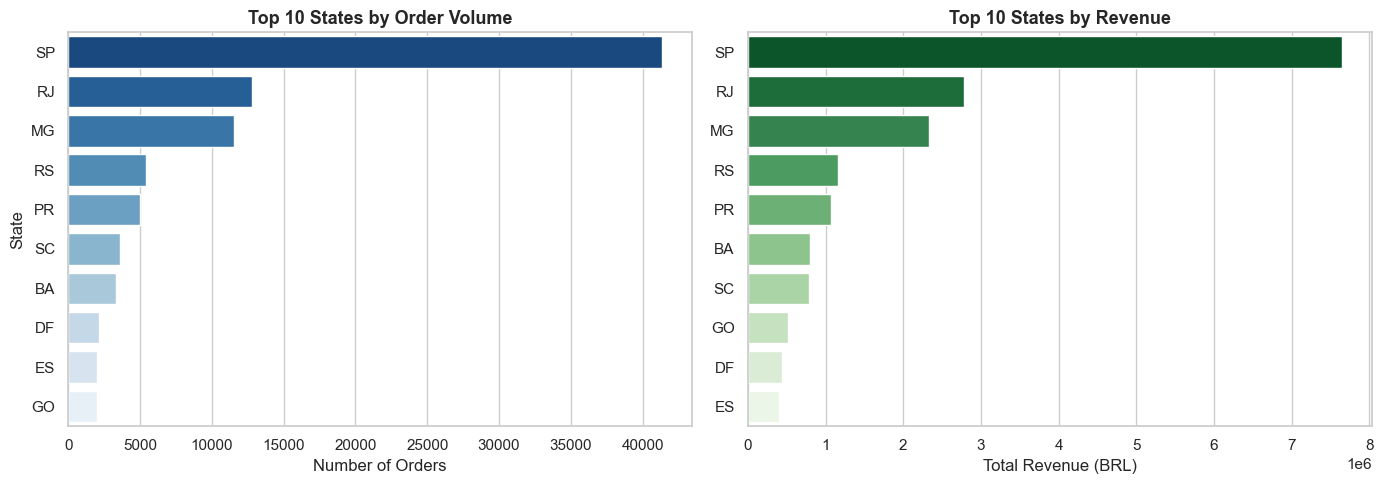

Saved to outputs/top_states.png


In [8]:
state_stats = (
    master
    .groupby('customer_state')
    .agg(
        total_orders  = ('order_id',      'nunique'),
        total_revenue = ('payment_value', 'sum')
    )
    .reset_index()
    .sort_values('total_orders', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=state_stats, x='total_orders', y='customer_state',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 States by Order Volume', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('State')

sns.barplot(data=state_stats.sort_values('total_revenue', ascending=False),
            x='total_revenue', y='customer_state',
            palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 States by Revenue', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/top_states.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/top_states.png')

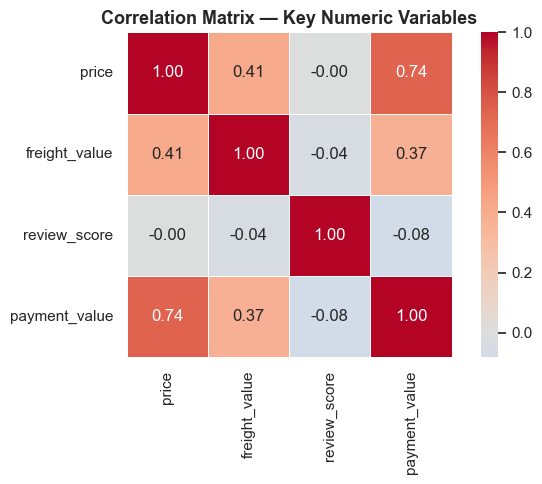

Saved to outputs/correlation_heatmap.png


In [9]:
corr_data = master[[
    'price', 'freight_value', 'review_score', 'payment_value'
]].dropna()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_data.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('Correlation Matrix — Key Numeric Variables',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/correlation_heatmap.png')

In [10]:
total_revenue   = dfs['order_payments']['payment_value'].sum()
total_orders    = dfs['orders']['order_id'].nunique()
total_customers = dfs['customers']['customer_unique_id'].nunique()
total_sellers   = dfs['sellers']['seller_id'].nunique()
avg_order_value = dfs['order_payments'].groupby('order_id')['payment_value'].sum().mean()
avg_review      = dfs['order_reviews']['review_score'].mean()
delivered       = dfs['orders'][dfs['orders']['order_status'] == 'delivered']
late_pct        = delivered['is_late'].mean() * 100
repeat_pct      = len(repeat_customers[repeat_customers['order_count'] > 1]) / len(customer_orders) * 100

print('=' * 50)
print('   WEEK 1 COMPLETE — OLIST ANALYTICS SUMMARY')
print('=' * 50)
print(f'  Total Revenue         : R$ {total_revenue:>12,.2f}')
print(f'  Total Orders          : {total_orders:>15,}')
print(f'  Unique Customers      : {total_customers:>15,}')
print(f'  Active Sellers        : {total_sellers:>15,}')
print(f'  Avg Order Value       : R$ {avg_order_value:>12,.2f}')
print(f'  Avg Review Score      : {avg_review:>15.2f} / 5.0')
print(f'  Late Delivery Rate    : {late_pct:>14.1f}%')
print(f'  Repeat Customer Rate  : {repeat_pct:>14.1f}%')
print('=' * 50)
print('\n✅ Week 1 Done: Data Loading, Cleaning, EDA complete')
print('📅 Next: Week 2 — SQL Analysis with SQLite (10 business queries)')

   WEEK 1 COMPLETE — OLIST ANALYTICS SUMMARY
  Total Revenue         : R$ 16,008,872.12
  Total Orders          :          99,441
  Unique Customers      :          96,096
  Active Sellers        :           3,095
  Avg Order Value       : R$       160.99
  Avg Review Score      :            4.09 / 5.0
  Late Delivery Rate    :            8.1%
  Repeat Customer Rate  :            3.1%

✅ Week 1 Done: Data Loading, Cleaning, EDA complete
📅 Next: Week 2 — SQL Analysis with SQLite (10 business queries)
